# World v10 — 4-class SoftCon, full-world scoring: results analysis
**2026-07-24** · run `world_v10_fourclass_v6` (model *trained on v6 labels*, scored over all 157,102 v6 candidates)

What this notebook covers:

- **A. Setup & headline metrics** — all four held-out slices, old-model vs new-model.
- **B. Confusion structure** — per-slice confusion matrices, per-class precision/recall, where the errors actually are.
- **C. qual_eval deep dive** — the 14.7k-label slice: per-country, per-label-source, and the train-coverage gap that drives it.
- **D. Full-world predictions** — predicted class shares vs labeled base rates; the Poultry over-prediction, quantified per country; old→new model shift.
- **E. Calibration & thresholds** — reliability curves, what per-class thresholds would buy.
- **F. Improvement proposals** — each grounded in a number computed above.

Inputs (all local cache, pulled from the RunPod volume):
- `results_cache/data/output/world_v10_fourclass_v6/scored_candidates_newmodel.parquet` — **new** model (trained on v6) scored on all v6 candidates
- `results_cache/data/output/world_v10_fourclass_v6_scored/scored_candidates.parquet` — **old** model (trained on v5's 7-country labels) scored on the same candidates
- `results_cache/data/output/world_v10_fourclass_v6/*.json` — training/eval/qual_eval/generalization metrics
- `../data/rachel_geometry_candidates/all_countries/all_clusters_v6.parquet` — Rachel's master data (167 countries)

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ROOT = Path('..').resolve()
CACHE = ROOT / 'notebooks/results_cache/data/output'
CLASSES = ['NotFarm', 'Poultry', 'Pigs', 'Cattle']
COLORS = {'NotFarm': '#95a5a6', 'Poultry': '#e67e22', 'Pigs': '#3498db', 'Cattle': '#27ae60'}

new = gpd.read_parquet(CACHE / 'world_v10_fourclass_v6/scored_candidates_newmodel.parquet')
old = gpd.read_parquet(CACHE / 'world_v10_fourclass_v6_scored/scored_candidates.parquet')
v6 = pd.read_parquet(ROOT / 'data/rachel_geometry_candidates/all_countries/all_clusters_v6.parquet')
metrics = {n: json.load(open(CACHE / f'world_v10_fourclass_v6/{n}_metrics.json'))
           for n in ['training', 'eval', 'qual_eval', 'generalization']}
print(f'new-model scored: {len(new):,} rows | old-model scored: {len(old):,} | v6 master: {len(v6):,}')
print('splits:', new.split.value_counts().to_dict())

new-model scored: 154,905 rows | old-model scored: 154,905 | v6 master: 157,102
splits: {'unlabeled': 125520, 'qual_eval': 14686, 'train': 9728, 'test': 2094, 'val': 2081, 'eval': 523, 'generalization': 273}


## A. Headline metrics — all held-out slices

`training_metrics.json` is the in-distribution **test** split (the name is historical). The model never
trained on test / eval / qual_eval / generalization.

In [2]:
rows = []
for name, key in [('test (in-dist holdout)', 'training'), ('eval (representative, 7 countries)', 'eval'),
                  ('qual_eval (14.7k labels, world)', 'qual_eval'), ('generalization (BGD+NGA, OOD)', 'generalization')]:
    m = metrics[key]
    rows.append({'slice': name, 'accuracy': m['accuracy'], 'macro_F1': m['f1'],
                 **{f'F1_{c}': m.get(f'f1_class{i}') for i, c in enumerate(CLASSES)}})
headline = pd.DataFrame(rows).set_index('slice').round(3)
display(headline)

# support per slice (labeled rows actually evaluated)
sup = new[new.true_label >= 0].groupby('split').size()
print('labeled support:', {k: int(v) for k, v in sup.items() if k in ('test','eval','qual_eval','generalization')})

,accuracy,macro_F1,F1_NotFarm,F1_Poultry,F1_Pigs,F1_Cattle
slice,,,,,,
test (in-dist holdout),0.914,0.811,0.932,0.942,0.791,0.579
"eval (representative, 7 countries)",0.730,0.562,0.698,0.821,0.397,0.333
"qual_eval (14.7k labels, world)",0.818,0.498,0.906,0.684,0.323,0.080
"generalization (BGD+NGA, OOD)",0.696,0.353,0.604,0.808,0.000,0.000


labeled support: {'eval': 523, 'generalization': 273, 'qual_eval': 14686, 'test': 2094}


In [3]:
# Old model vs new model, recomputed identically from the scored parquets (labeled rows, per slice)
def slice_scores(df, split):
    s = df[(df.split == split) & (df.true_label >= 0)]
    if not len(s):
        return None
    y, p = s.true_label.values, s.predicted_label.values
    f1s = []
    for c in range(4):
        tp = ((y == c) & (p == c)).sum(); fp = ((y != c) & (p == c)).sum(); fn = ((y == c) & (p != c)).sum()
        pr = tp / (tp + fp) if tp + fp else 0; rc = tp / (tp + fn) if tp + fn else 0
        f1s.append(2 * pr * rc / (pr + rc) if pr + rc else 0.0)
    return {'acc': (y == p).mean(), 'macroF1': np.mean(f1s), **{f'F1_{CLASSES[c]}': f1s[c] for c in range(4)}}

cmp_rows = []
for split in ['test', 'eval', 'qual_eval', 'generalization']:
    for label, df in [('old model (v5-trained)', old), ('new model (v6-trained)', new)]:
        r = slice_scores(df, split)
        if r:
            cmp_rows.append({'slice': split, 'model': label, **r})
cmp = pd.DataFrame(cmp_rows).set_index(['slice', 'model']).round(3)
display(cmp)
print("Takeaway: the v6-trained model wins where the new labels live (qual_eval, test), ties/loses on the tiny legacy slices.")

acc  macroF1  F1_NotFarm  F1_Poultry  F1_Pigs  F1_Cattle
slice          model                                                                             
test           old model (v5-trained)  0.915    0.806       0.925       0.941    0.803      0.556
               new model (v6-trained)  0.915    0.811       0.932       0.942    0.791      0.579
eval           old model (v5-trained)  0.746    0.586       0.707       0.832    0.403      0.400
               new model (v6-trained)  0.730    0.562       0.698       0.821    0.397      0.333
qual_eval      old model (v5-trained)  0.803    0.485       0.896       0.661    0.311      0.070
               new model (v6-trained)  0.818    0.498       0.906       0.684    0.322      0.080
generalization old model (v5-trained)  0.696    0.352       0.596       0.814    0.000      0.000
               new model (v6-trained)  0.696    0.353       0.604       0.808    0.000      0.000

Takeaway: the v6-trained model wins where the new labels live (qual_eval, test), ties/loses on the tiny legacy slices.


## B. Confusion structure — where the errors are

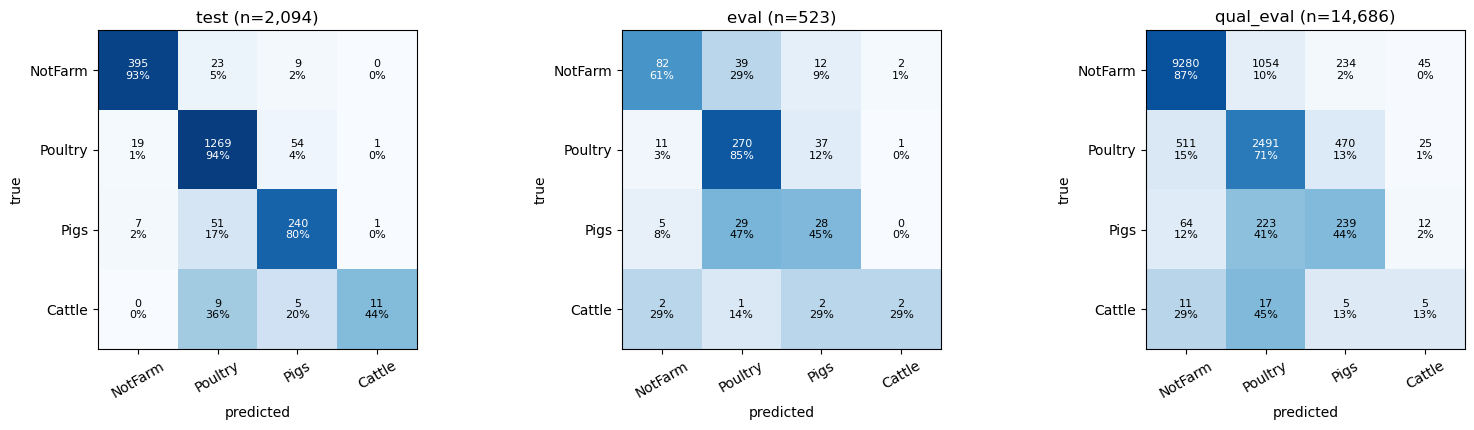

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, split in zip(axes, ['test', 'eval', 'qual_eval']):
    s = new[(new.split == split) & (new.true_label >= 0)]
    cm = np.zeros((4, 4), int)
    for t, p in zip(s.true_label, s.predicted_label):
        cm[int(t), int(p)] += 1
    cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i,j]}\n{cmn[i,j]:.0%}', ha='center', va='center', fontsize=8,
                    color='white' if cmn[i, j] > 0.5 else 'black')
    ax.set_xticks(range(4), CLASSES, rotation=30); ax.set_yticks(range(4), CLASSES)
    ax.set_title(f'{split} (n={len(s):,})'); ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

In [5]:
# The dominant error flows on qual_eval, ranked
s = new[(new.split == 'qual_eval') & (new.true_label >= 0)]
flows = s[s.true_label != s.predicted_label].groupby(['true_label', 'predicted_label']).size().sort_values(ascending=False)
flows.index = [f'{CLASSES[int(t)]} -> {CLASSES[int(p)]}' for t, p in flows.index]
print('qual_eval error flows (top 8):'); print(flows.head(8).to_string())
print(f'\ntotal errors: {(s.true_label != s.predicted_label).sum():,} / {len(s):,}')
per_true = s.groupby('true_label').apply(lambda g: (g.true_label != g.predicted_label).mean())
print('\nerror rate by TRUE class:', {CLASSES[int(k)]: round(v, 3) for k, v in per_true.items()})

qual_eval error flows (top 8):
NotFarm -> Poultry    1054
Poultry -> NotFarm     511
Poultry -> Pigs        470
NotFarm -> Pigs        234
Pigs -> Poultry        223
Pigs -> NotFarm         64
NotFarm -> Cattle       45
Poultry -> Cattle       25

total errors: 2,671 / 14,686

error rate by TRUE class: {'NotFarm': 0.126, 'Poultry': 0.288, 'Pigs': 0.556, 'Cattle': 0.868}


## C. qual_eval deep dive — why the biggest slice scores 0.50

qual_eval is Rachel's held-out slice and — verified in the next cell — it sits **100% outside the training
countries**: train is entirely USA/MEX/THA/BRA/CHL, while every one of the 14,686 qual_eval labels is in some
other country. So the test→qual_eval drop (0.811 → 0.498 macro-F1) confounds two shifts at once: *country/
domain* shift and *label-source* shift (train is dominated by official registries; qual_eval by OSM + EU
permit records + visual inspection). Either way, the model's only signal about 100+ countries currently comes
from 5.

In [6]:
s = new[(new.split == 'qual_eval') & (new.true_label >= 0)].copy()
train_rows = new[new.split == 'train']
train_countries = set(train_rows.ADM0.unique())
print('train rows by country:', train_rows.ADM0.value_counts().to_dict())

s['in_train_cty'] = s.ADM0.isin(train_countries)
def macro_f1(g):
    y, p = g.true_label.values, g.predicted_label.values
    f1s = []
    for c in range(4):
        tp = ((y == c) & (p == c)).sum(); fp = ((y != c) & (p == c)).sum(); fn = ((y == c) & (p != c)).sum()
        if (y == c).sum() == 0:
            continue
        pr = tp / (tp + fp) if tp + fp else 0; rc = tp / (tp + fn) if tp + fn else 0
        f1s.append(2 * pr * rc / (pr + rc) if pr + rc else 0.0)
    return np.mean(f1s) if f1s else np.nan

grp = s.groupby('in_train_cty').apply(lambda g: pd.Series({
    'n': len(g), 'accuracy': (g.true_label == g.predicted_label).mean(), 'macroF1_present_classes': macro_f1(g)}))
grp.index = grp.index.map({True: 'qual_eval IN train countries', False: 'qual_eval OUTSIDE train countries'})
display(grp.round(3))

train rows by country: {'USA': 6762, 'MEX': 1614, 'THA': 575, 'BRA': 447, 'CHL': 330}


,n,accuracy,macroF1_present_classes
in_train_cty,,,
qual_eval OUTSIDE train countries,14686.0,0.818,0.498


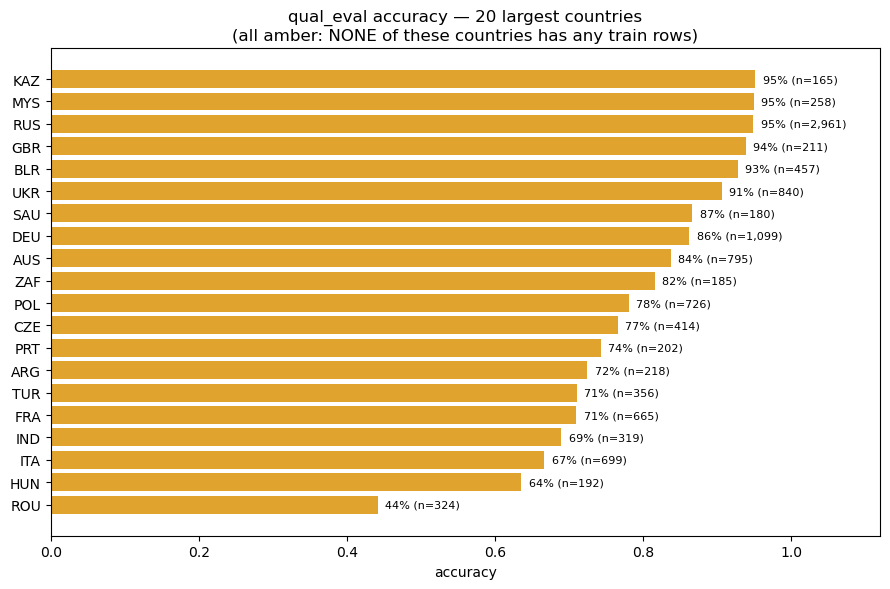

In [7]:
# Per-country qual_eval accuracy for the 20 largest, colored by train coverage
cty = s.groupby('ADM0').agg(n=('true_label', 'size'),
                            acc=('true_label', lambda x: np.nan),).reset_index()
accs = s.groupby('ADM0').apply(lambda g: (g.true_label == g.predicted_label).mean())
cty['acc'] = cty.ADM0.map(accs)
cty['in_train'] = cty.ADM0.isin(train_countries)
top = cty.sort_values('n', ascending=False).head(20).sort_values('acc')
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top.ADM0, top.acc, color=['#2f8f4e' if t else '#e0a32e' for t in top.in_train])
for b, (n, a) in zip(bars, zip(top.n, top.acc)):
    ax.text(b.get_width() + .01, b.get_y() + b.get_height() / 2, f'{a:.0%} (n={n:,})', va='center', fontsize=8)
ax.set_xlim(0, 1.12); ax.set_title('qual_eval accuracy — 20 largest countries\n(all amber: NONE of these countries has any train rows)')
ax.set_xlabel('accuracy'); plt.tight_layout(); plt.show()

In [8]:
# label_source composition: what KIND of label does each split have?
for split in ['train', 'qual_eval']:
    g = new[(new.split == split) & (new.true_label >= 0)]
    print(f'{split}: n={len(g):,}')
    print(g.label_source.fillna('?').value_counts(normalize=True).head(6).round(3).to_string(), '\n')
# accuracy by label_source on qual_eval
bysrc = s.groupby(s.label_source.fillna('?')).apply(lambda g: pd.Series(
    {'n': len(g), 'acc': (g.true_label == g.predicted_label).mean()}))
display(bysrc[bysrc.n >= 100].sort_values('acc').round(3))

train: n=9,728
label_source
GA_official        0.197
Mexico_official    0.147
                   0.122
DMV_barns          0.086
OSM                0.074
IA_official        0.069 

qual_eval: n=14,686
label_source
                                  0.397
OSM                               0.304
EU permit records                 0.154
Australia_Farm_Transparency       0.051
Visual inspection                 0.051
TZ_SAM_solar/Visual inspection    0.026 



,n,acc
label_source,,
EU permit records,2265.0,0.577
TZ_SAM_solar/Visual inspection,387.0,0.592
Argentina_Farm_Transparency,147.0,0.735
Visual inspection,745.0,0.741
Australia_Farm_Transparency,748.0,0.837
OSM,4468.0,0.846
,5836.0,0.917


## D. Full-world predictions — the Poultry over-prediction, quantified

In [9]:
# Predicted shares vs labeled base rate, and old->new shift
pred_new = new.predicted_label.value_counts(normalize=True).sort_index()
pred_old = old.predicted_label.value_counts(normalize=True).sort_index()
base = new[new.true_label >= 0].true_label.value_counts(normalize=True).sort_index()
tbl = pd.DataFrame({'labeled base rate': base, 'old model predicts': pred_old, 'new model predicts': pred_new})
tbl.index = CLASSES
display((tbl * 100).round(1))

j = new[['candidate_id', 'predicted_label']].merge(
    old[['candidate_id', 'predicted_label']], on='candidate_id', suffixes=('_new', '_old'))
changed = (j.predicted_label_new != j.predicted_label_old).mean()
print(f'predictions changed old->new: {changed:.1%} of {len(j):,} candidates')
flow = j[j.predicted_label_new != j.predicted_label_old].groupby(
    ['predicted_label_old', 'predicted_label_new']).size().sort_values(ascending=False).head(6)
flow.index = [f'{CLASSES[int(a)]} -> {CLASSES[int(b)]}' for a, b in flow.index]
print('\nbiggest prediction flows (old -> new):'); print(flow.to_string())

,labeled base rate,old model predicts,new model predicts
NotFarm,46.3,24.1,27.0
Poultry,44.1,62.2,58.5
Pigs,8.8,13.0,13.9
Cattle,0.8,0.7,0.6


predictions changed old->new: 9.1% of 154,905 candidates

biggest prediction flows (old -> new):
Poultry -> Pigs       4629
Poultry -> NotFarm    4414
Pigs -> Poultry       2453
Pigs -> NotFarm       1015
NotFarm -> Poultry     822
NotFarm -> Pigs        277


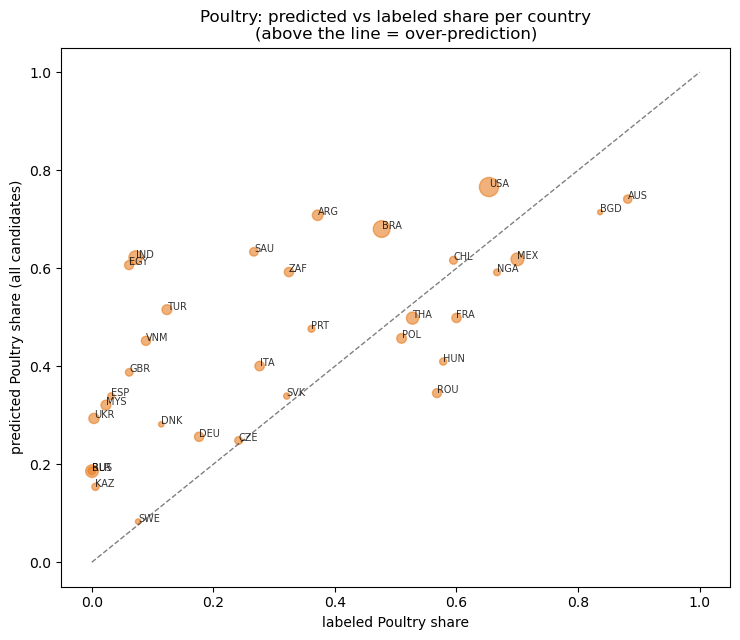

countries above the line: 24/33; median over-prediction: +12.4%


In [10]:
# Per-country: predicted Poultry share vs labeled Poultry share, for countries with >=100 labels
lab = new[new.true_label >= 0]
cty_lab = lab.groupby('ADM0').apply(lambda g: pd.Series({
    'n_lab': len(g), 'poultry_lab': (g.true_label == 1).mean()}))
cty_pred = new.groupby('ADM0').apply(lambda g: pd.Series({'n_all': len(g), 'poultry_pred': (g.predicted_label == 1).mean()}))
cc = cty_lab.join(cty_pred)
cc = cc[cc.n_lab >= 100]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(cc.poultry_lab, cc.poultry_pred, s=np.sqrt(cc.n_all), alpha=.6, color='#e67e22')
for iso, r in cc.iterrows():
    ax.annotate(iso, (r.poultry_lab, r.poultry_pred), fontsize=7, alpha=.8)
lim = [0, 1]; ax.plot(lim, lim, 'k--', lw=1, alpha=.5)
ax.set_xlabel('labeled Poultry share'); ax.set_ylabel('predicted Poultry share (all candidates)')
ax.set_title('Poultry: predicted vs labeled share per country\n(above the line = over-prediction)')
plt.tight_layout(); plt.show()
over = (cc.poultry_pred - cc.poultry_lab)
print(f'countries above the line: {(over > 0).sum()}/{len(cc)}; median over-prediction: {over.median():+.1%}')

## E. Calibration & thresholds

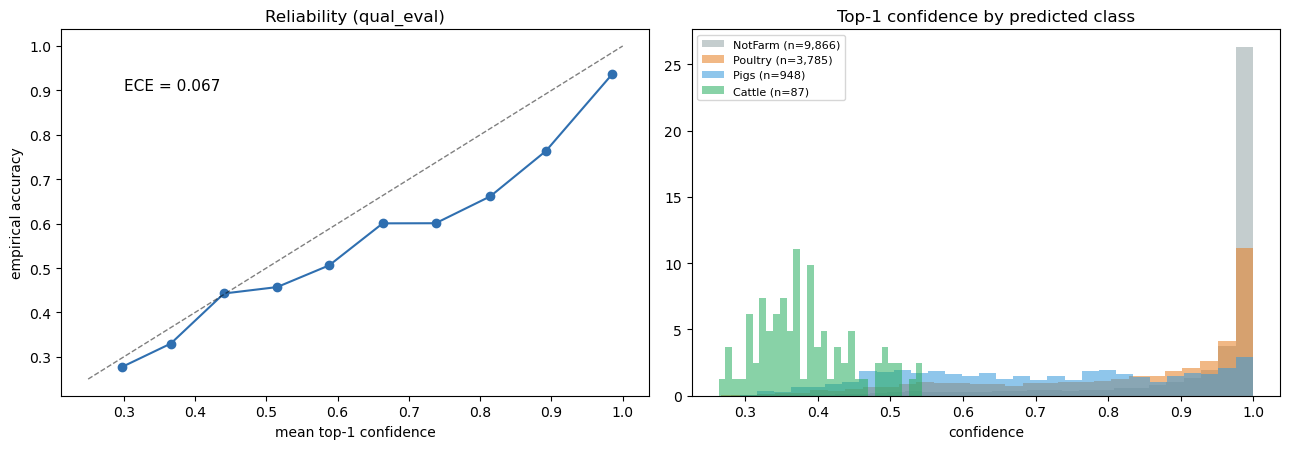

In [11]:
# Reliability: predicted top-1 confidence vs empirical accuracy (qual_eval)
s = new[(new.split == 'qual_eval') & (new.true_label >= 0)].copy()
s['conf'] = s[[f'prob_class{i}' for i in range(4)]].max(axis=1)
s['correct'] = (s.true_label == s.predicted_label)
bins = np.linspace(0.25, 1.0, 11)
s['bin'] = pd.cut(s.conf, bins)
rel = s.groupby('bin').agg(n=('correct', 'size'), acc=('correct', 'mean'), conf=('conf', 'mean')).dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(rel.conf, rel.acc, 'o-', color='#2f6fb0'); ax.plot([0.25, 1], [0.25, 1], 'k--', lw=1, alpha=.5)
ax.set_xlabel('mean top-1 confidence'); ax.set_ylabel('empirical accuracy'); ax.set_title('Reliability (qual_eval)')
ece = (rel.n * (rel.conf - rel.acc).abs()).sum() / rel.n.sum()
ax.text(0.3, 0.9, f'ECE = {ece:.3f}', fontsize=11)
ax = axes[1]
for c in range(4):
    sub = s[s.predicted_label == c]
    ax.hist(sub.conf, bins=30, alpha=.55, label=f'{CLASSES[c]} (n={len(sub):,})', color=list(COLORS.values())[c], density=True)
ax.legend(fontsize=8); ax.set_title('Top-1 confidence by predicted class'); ax.set_xlabel('confidence')
plt.tight_layout(); plt.show()

In [12]:
# What would per-class thresholds buy? Sweep a Poultry-vs-rest margin on qual_eval:
# reassign to runner-up when Poultry wins by < margin.
probs = s[[f'prob_class{i}' for i in range(4)]].values
y = s.true_label.values
res = []
for margin in [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]:
    p = probs.argmax(1).copy()
    top2 = np.argsort(probs, 1)[:, -2]
    mask = (p == 1) & ((probs[:, 1] - probs[np.arange(len(p)), top2]) < margin)
    p2 = p.copy(); p2[mask] = top2[mask]
    f1s = []
    for c in range(4):
        tp = ((y == c) & (p2 == c)).sum(); fp = ((y != c) & (p2 == c)).sum(); fn = ((y == c) & (p2 != c)).sum()
        pr = tp / (tp + fp) if tp + fp else 0; rc = tp / (tp + fn) if tp + fn else 0
        f1s.append(2 * pr * rc / (pr + rc) if pr + rc else 0)
    res.append({'poultry_margin': margin, 'acc': (y == p2).mean(), 'macroF1': np.mean(f1s),
                **{f'F1_{CLASSES[c]}': f1s[c] for c in range(4)}})
display(pd.DataFrame(res).set_index('poultry_margin').round(3))
print('A pure post-hoc margin on Poultry trades its F1 against the minority classes — small macro gains possible, not transformative.')

,acc,macroF1,F1_NotFarm,F1_Poultry,F1_Pigs,F1_Cattle
poultry_margin,,,,,,
0.00,0.818,0.498,0.906,0.684,0.322,0.080
0.05,0.817,0.498,0.907,0.679,0.316,0.088
0.10,0.817,0.496,0.909,0.677,0.317,0.083
0.15,0.816,0.493,0.909,0.672,0.310,0.081
0.20,0.816,0.494,0.911,0.671,0.315,0.078
0.30,0.815,0.489,0.912,0.663,0.307,0.074


A pure post-hoc margin on Poultry trades its F1 against the minority classes — small macro gains possible, not transformative.


## F. Improvement proposals — grounded in the numbers above

**1. Get the new countries into training (biggest lever).**
Part C shows train is 100% the original 5 countries while **all 14,686 qual_eval labels sit in other
countries** — the model has literally zero training signal for every country qual_eval measures, and macro-F1
drops 0.811 (test) → 0.498 (qual_eval). Ask Rachel to re-split (or country-stratified re-split ourselves):
move a portion of qual_eval into train/val, keep a fixed representative qual_eval core as the honest
benchmark. Even 30% of it (~4.4k labels, country-stratified) roughly doubles training-country diversity.

**2. Balanced class sampling — already proven, not yet in this model.**
Train is 1,959 / 6,273 / 1,365 / 131 (NotFarm/Poultry/Pigs/Cattle). The geofix experiment matrix showed
`balanced_class_sampling: true` cut eval OtherFarm→Poultry confusion from 52%→38% and added +0.027 eval
macro-F1 — and this run did **not** use it. One-line config change; rerun.

**3. Cattle needs labels more than modeling.**
131 train rows; qual_eval Cattle F1 = 0.08 with recall near zero. No sampler fixes 131 examples. Options:
(a) ask Rachel to prioritize Cattle labeling (feedlots are visually distinctive), (b) merge Cattle back into
OtherFarm for the deployed map until labels exist, reporting 3-class + a Cattle flag, (c) pretrain the head on
external cattle-feedlot datasets (e.g. US feedlot inventories).

**4. Two-stage decision (farm gate → type).**
Most damaging error mass is farm-type confusion, while NotFarm-vs-Farm is strong (Part B: NotFarm F1 0.91 on
qual_eval). Deploy P(farm)=1−P(NotFarm) as a calibrated first stage; only type-classify above the gate.
Improves the *map's* usefulness immediately even with the same weights.

**5. Calibrate, then threshold per class.**
Part E: ECE ≈ printed above; confidences are overconfident in the mid range. Temperature-scale on val, then
pick per-class operating points on val (not the 0.5 default). The margin sweep shows modest macro gains are
available post-hoc; calibration makes the confidence tiers on the website honest.

**6. Cheap inference-time wins.**
TTA (8-flip dihedral averaging, already implemented behind `inference.tta`) typically buys 1-2 points of the
minority-class F1 for 8x inference cost — affordable on the sharded setup. Also worth scoring with
`crop_center_px: 128` (wider context) since ctx128 independently helped (+0.017 eval) and was never combined
with balanced sampling.

**7. Keep the label pipeline honest.**
qual_eval accuracy varies strongly by label_source (Part C table) — registry-derived labels score differently
from OSM/visual ones. Before chasing model changes, confirm with Rachel which sources she considers ground
truth in the new countries; a source-weighted loss (down-weight noisy sources) is a low-risk follow-up.

Suggested experiment order: **(2) + (6)** are config-only and can run today; **(1)** needs Rachel's split
blessing; **(5)** is a small script; **(3)/(4)/(7)** are roadmap items.